# 모바일 BLE 스캔 정보 (mBle) 심층 EDA

이 노트북은 주변 Bluetooth Low Energy 기기를 스캔한 `ch2025_mBle.parquet` 파일을 파헤칩니다.
주변 기기 수는 외출 상태이거나 사람이 많은 곳에 있는지를 식별하는 유용한 단서가 됩니다.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 테마 설정 시 폰트 정보를 함께 주입하여 덮어쓰기 방지 (Windows/Mac/Linux 대응)
sns.set_theme(
    style="whitegrid",
    rc={
        "font.family": "sans-serif",
        "font.sans-serif": [
            "Malgun Gothic",
            "AppleGothic",
            "NanumGothic",
            "DejaVu Sans",
            "Arial",
            "Helvetica",
            "sans-serif",
        ],
        "axes.unicode_minus": False,
    },
)
plt.rcParams["figure.figsize"] = (12, 6)

# 현재 스크립트/노트북 위치 기준의 절대 경로 기준점 정의 (어디서 실행해도 경로 에러 방지)
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in locals() else os.getcwd()

DATA_PATH = os.path.join(BASE_DIR, "../../data/ch2025_data_items/ch2025_mBle.parquet")
df = pd.read_parquet(DATA_PATH)

## 1. 데이터 확인

In [2]:
print(f"데이터 크기 (Shape): {df.shape}")
df.head()

데이터 크기 (Shape): (21830, 3)


,subject_id,timestamp,m_ble
0,id01,2024-06-26 12:13:00,"[{'address': '00:15:7C:11:80:8D', 'device_clas..."
1,id01,2024-06-26 12:23:00,"[{'address': '0A:B1:26:4D:76:21', 'device_clas..."
2,id01,2024-06-26 12:33:00,"[{'address': '04:F5:AE:39:95:E0', 'device_clas..."
3,id01,2024-06-26 13:23:00,"[{'address': '06:C0:D2:6D:9F:69', 'device_clas..."
4,id01,2024-06-26 14:23:00,"[{'address': '10:2B:41:74:9F:B1', 'device_clas..."


## 2. 스캔별 감지된 기기 수 분석
한 번의 스캔에서 평균적으로 몇 개의 기기가 잡히는지 분석합니다.

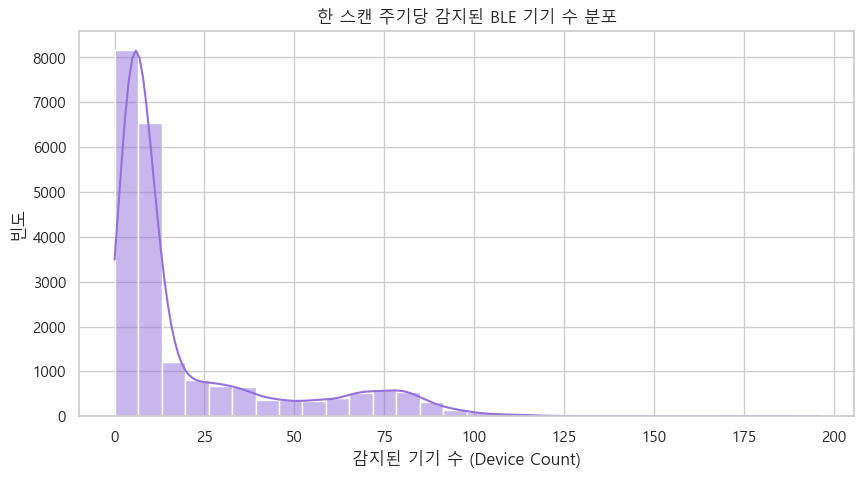

In [3]:
df["device_count"] = df["m_ble"].apply(lambda x: len(x) if x is not None else 0)

plt.figure(figsize=(10, 5))
sns.histplot(df["device_count"], bins=30, kde=True, color="mediumpurple")
plt.title("한 스캔 주기당 감지된 BLE 기기 수 분포")
plt.xlabel("감지된 기기 수 (Device Count)")
plt.ylabel("빈도")
plt.show()

In [4]:
df["device_count"].describe()

count    21830.000000
mean        20.020797
std         25.127357
min          0.000000
25%          5.000000
50%          8.000000
75%         23.000000
max        196.000000
Name: device_count, dtype: float64

## 3. 참여자별 주변 BLE 기기 수 비교

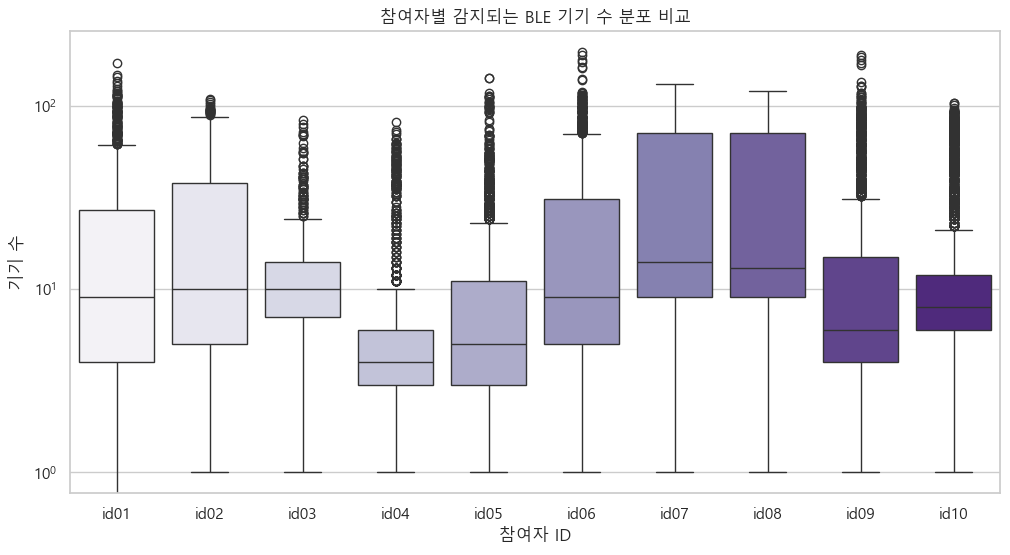

In [5]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="subject_id", y="device_count", hue="subject_id", palette="Purples", legend=False)
plt.title("참여자별 감지되는 BLE 기기 수 분포 비교")
plt.xlabel("참여자 ID")
plt.ylabel("기기 수")
plt.yscale("log")  # 편차가 클 경우 로그 스케일 적용
plt.show()

## 4. 시간대별 BLE 기기 수 흐름

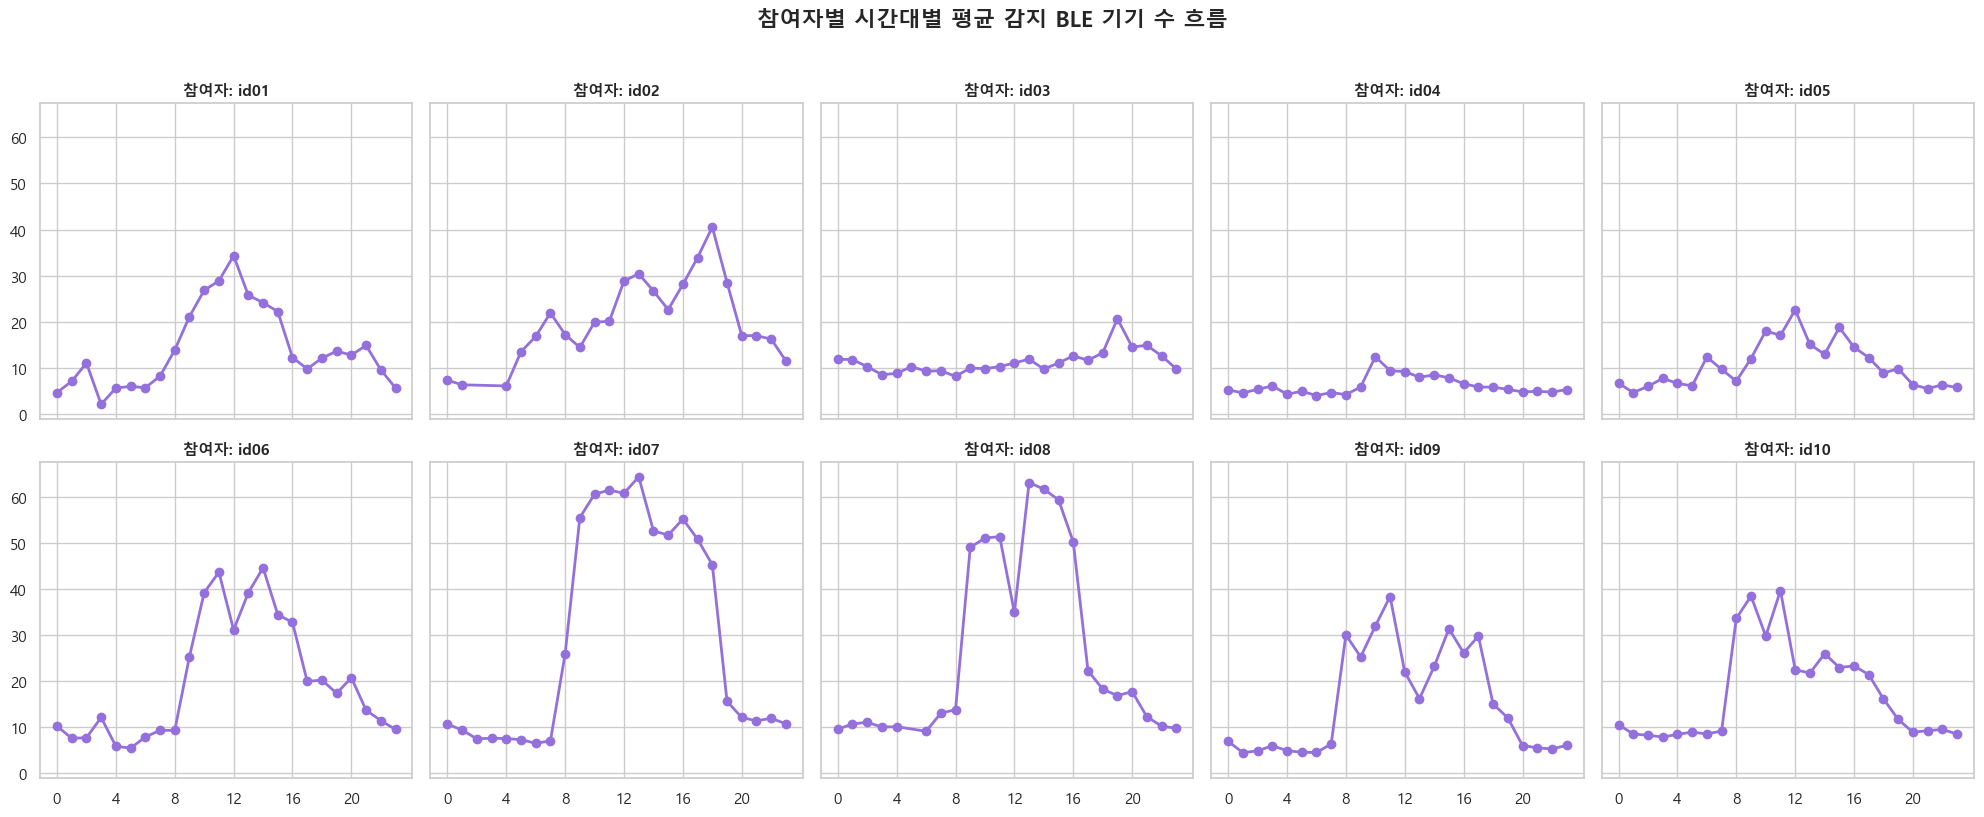

In [6]:
df["hour"] = df["timestamp"].dt.hour
hourly_ble = df.groupby(["subject_id", "hour"])["device_count"].mean().reset_index()

subjects = sorted(df["subject_id"].unique())
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, sub in enumerate(subjects):
    sub_data = hourly_ble[hourly_ble["subject_id"] == sub]
    axes[idx].plot(sub_data["hour"], sub_data["device_count"], color="mediumpurple", linewidth=2, marker="o")
    axes[idx].set_title(f"참여자: {sub}", fontsize=11, fontweight="bold")
    axes[idx].set_xticks(range(0, 24, 4))

plt.suptitle("참여자별 시간대별 평균 감지 BLE 기기 수 흐름", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 5. BLE 신호 강도 (RSSI) 분석
주변 기기와의 수신 신호 강도(RSSI) 분포를 분석합니다. 
RSSI는 음수 값을 가지며, 0에 가까울수록 물리적 거리가 가까움을 의미합니다.

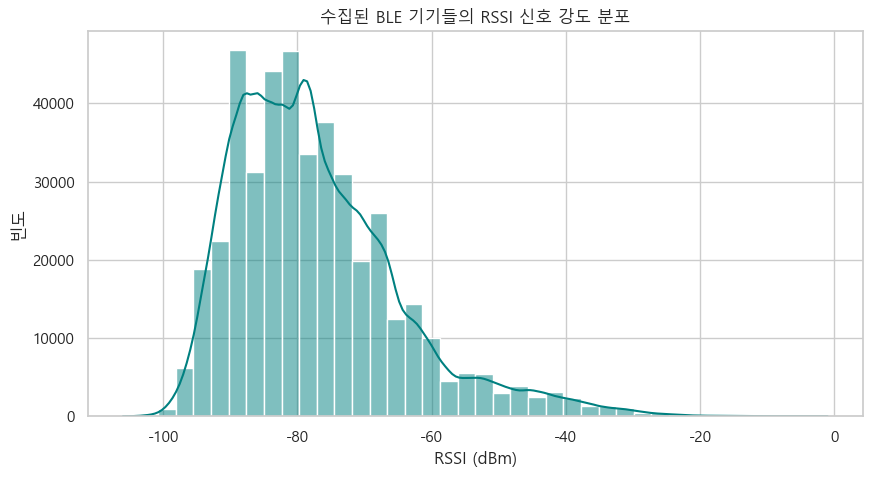

In [7]:
# 기기 단위로 평탄화
flat_ble = df.explode("m_ble").dropna(subset=["m_ble"])
flat_ble["address"] = flat_ble["m_ble"].str["address"]
flat_ble["rssi"] = flat_ble["m_ble"].str["rssi"].astype(float)
flat_ble = flat_ble.drop(columns=["m_ble"])

# 5.1 RSSI 분포 시각화
plt.figure(figsize=(10, 5))
sns.histplot(flat_ble["rssi"], bins=40, kde=True, color="teal")
plt.title("수집된 BLE 기기들의 RSSI 신호 강도 분포")
plt.xlabel("RSSI (dBm)")
plt.ylabel("빈도")
plt.show()

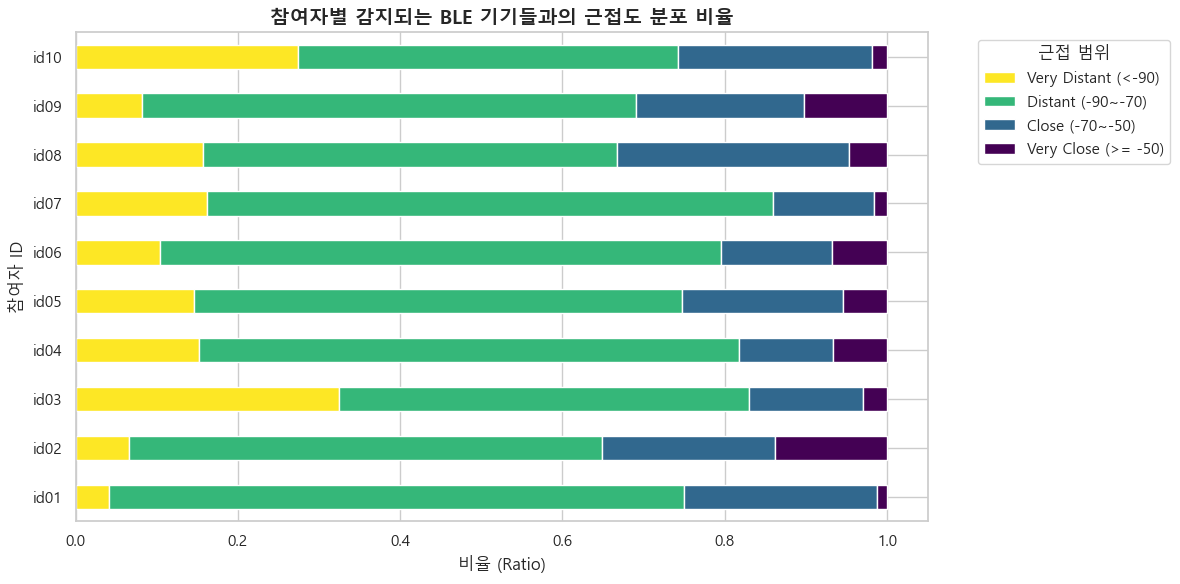

In [8]:
# 5.2 참여자별 기기 근접도 분포 비율 비교 (누적 바 차트)
flat_ble["proximity"] = pd.cut(
    flat_ble["rssi"], 
    bins=[-float("inf"), -90, -70, -50, float("inf")], 
    labels=["Very Distant (<-90)", "Distant (-90~-70)", "Close (-70~-50)", "Very Close (>= -50)"]
)
proximity_pivot = pd.crosstab(flat_ble["subject_id"], flat_ble["proximity"], normalize="index")

proximity_pivot.plot(kind="barh", stacked=True, figsize=(12, 6), cmap="viridis_r")
plt.title("참여자별 감지되는 BLE 기기들과의 근접도 분포 비율", fontsize=14, fontweight="bold")
plt.xlabel("비율 (Ratio)")
plt.ylabel("참여자 ID")
plt.legend(title="근접 범위", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

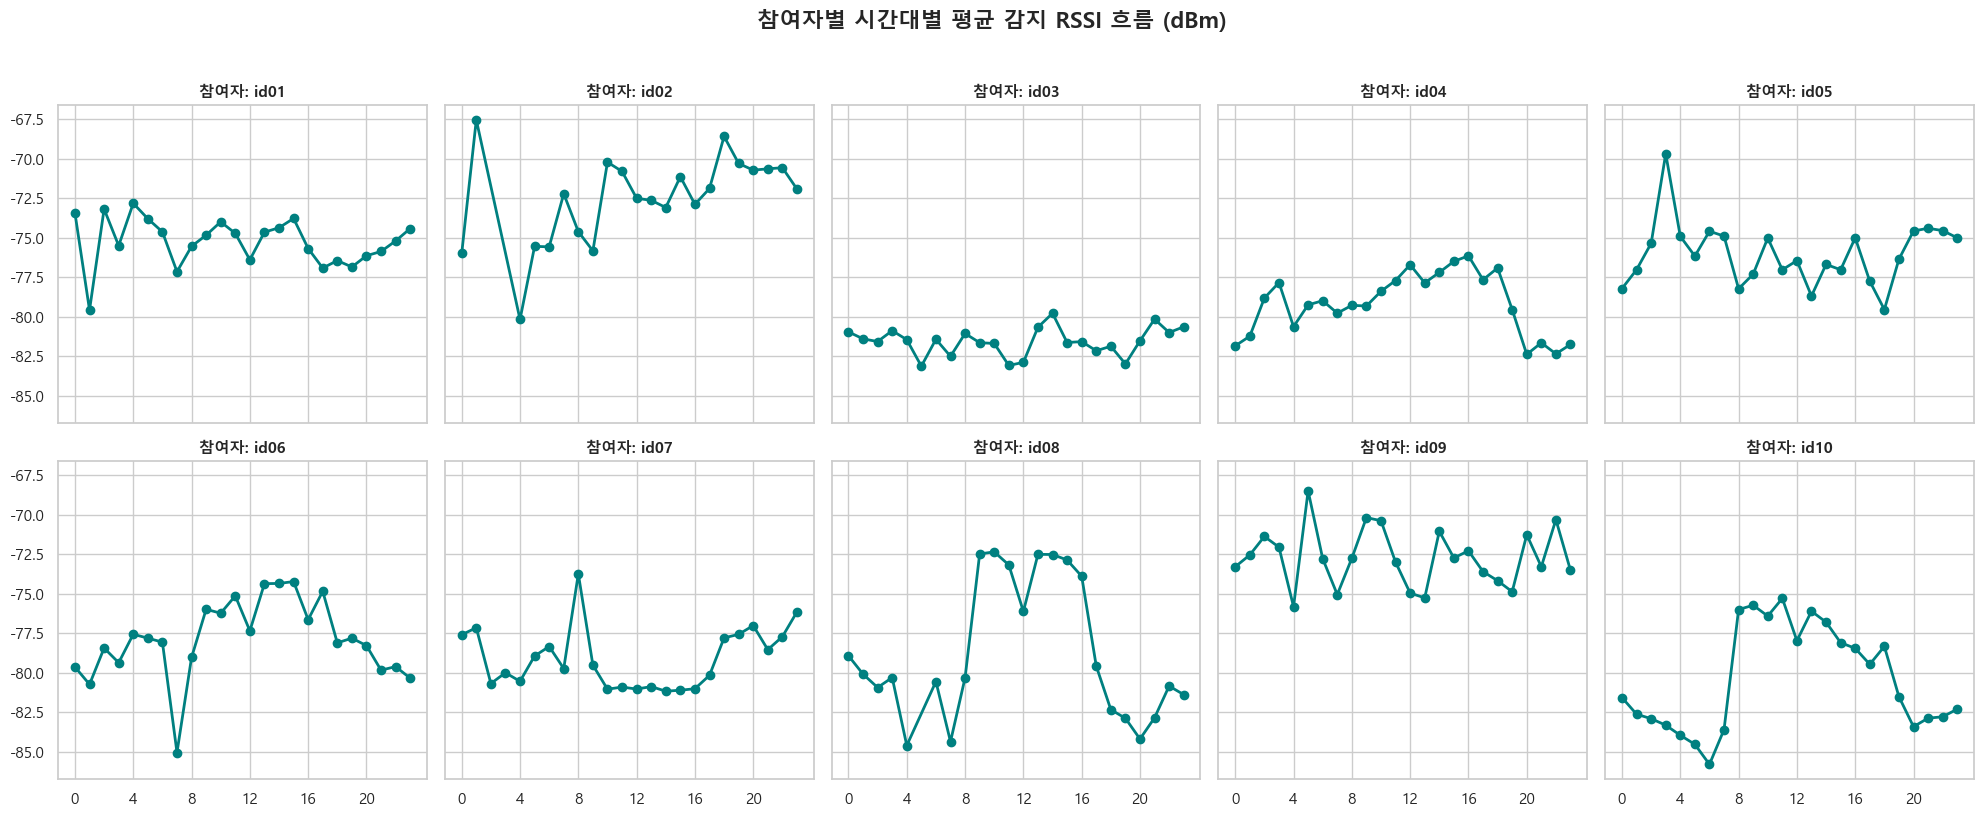

In [9]:
# 5.3 참여자별 시간대별 평균 RSSI 흐름 (2x5 서브플롯)
flat_ble["hour"] = flat_ble["timestamp"].dt.hour
hourly_rssi = flat_ble.groupby(["subject_id", "hour"])["rssi"].mean().reset_index()

subjects = sorted(flat_ble["subject_id"].unique())
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, sub in enumerate(subjects):
    sub_data = hourly_rssi[hourly_rssi["subject_id"] == sub]
    axes[idx].plot(sub_data["hour"], sub_data["rssi"], color="teal", linewidth=2, marker="o")
    axes[idx].set_title(f"참여자: {sub}", fontsize=11, fontweight="bold")
    axes[idx].set_xticks(range(0, 24, 4))

plt.suptitle("참여자별 시간대별 평균 감지 RSSI 흐름 (dBm)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 6. 피처 엔지니어링 제안
* **`ble_devices_mean`**: 하루 동안 감지된 평균 BLE 디바이스 개수 (주변 환경 혼잡도).
* **`ble_devices_max`**: 하루 동안 감지된 최대 BLE 디바이스 개수 (이동성 및 혼잡도 피크).
* **`ble_rssi_mean`**: 수집된 기기들의 평균 RSSI 신호 강도 (기기들과의 물리적 거리 가늠 피처).
* **`ble_close_devices_ratio`**: 하루 중 초근접(예: RSSI >= -60 dBm) 기기가 차지하는 비율.